In [13]:
%pip install scikit-learn
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
  Using cached matplotlib-3.10.8-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp314-cp314-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.8 MB)
Using cached contourpy-1.3.3-cp314-cp314-manylinux_2_27_x86_64.manylinux

In [14]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Load data and split
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 2. Train an UNPRUNED tree
clf_unpruned = DecisionTreeClassifier(random_state=42)
clf_unpruned.fit(X_train, y_train)

print(f"Unpruned Training Accuracy: {clf_unpruned.score(X_train, y_train):.3f}")
print(f"Unpruned Testing Accuracy: {clf_unpruned.score(X_test, y_test):.3f}")
print(f"Unpruned Tree Depth: {clf_unpruned.get_depth()}")

Unpruned Training Accuracy: 1.000
Unpruned Testing Accuracy: 0.951
Unpruned Tree Depth: 7


In [15]:
# Train a PREPRUNED tree
# We restrict depth, enforce minimum samples per split, and minimum samples per leaf
clf_prepruned = DecisionTreeClassifier(
    max_depth=3,               # Stop growing at depth 3
    min_samples_split=10,      # Need at least 10 samples to split a node
    min_samples_leaf=5,        # Each leaf must have at least 5 samples
    random_state=42
)

clf_prepruned.fit(X_train, y_train)

print(f"Prepruned Training Accuracy: {clf_prepruned.score(X_train, y_train):.3f}")
print(f"Prepruned Testing Accuracy: {clf_prepruned.score(X_test, y_test):.3f}")
print(f"Prepruned Tree Depth: {clf_prepruned.get_depth()}")

Prepruned Training Accuracy: 0.967
Prepruned Testing Accuracy: 0.958
Prepruned Tree Depth: 3


In [16]:
# 1. Extract the available ccp_alphas from the unpruned tree
path = clf_unpruned.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# 2. Train a tree for each alpha and store them
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

# 3. Evaluate all trees and find the best one
test_scores = [clf.score(X_test, y_test) for clf in clfs]
best_index = test_scores.index(max(test_scores))
best_clf_postpruned = clfs[best_index]

print(f"Best ccp_alpha: {ccp_alphas[best_index]:.4f}")
print(f"Postpruned Training Accuracy: {best_clf_postpruned.score(X_train, y_train):.3f}")
print(f"Postpruned Testing Accuracy: {best_clf_postpruned.score(X_test, y_test):.3f}")
print(f"Postpruned Tree Depth: {best_clf_postpruned.get_depth()}")

Best ccp_alpha: 0.0046
Postpruned Training Accuracy: 0.991
Postpruned Testing Accuracy: 0.958
Postpruned Tree Depth: 4


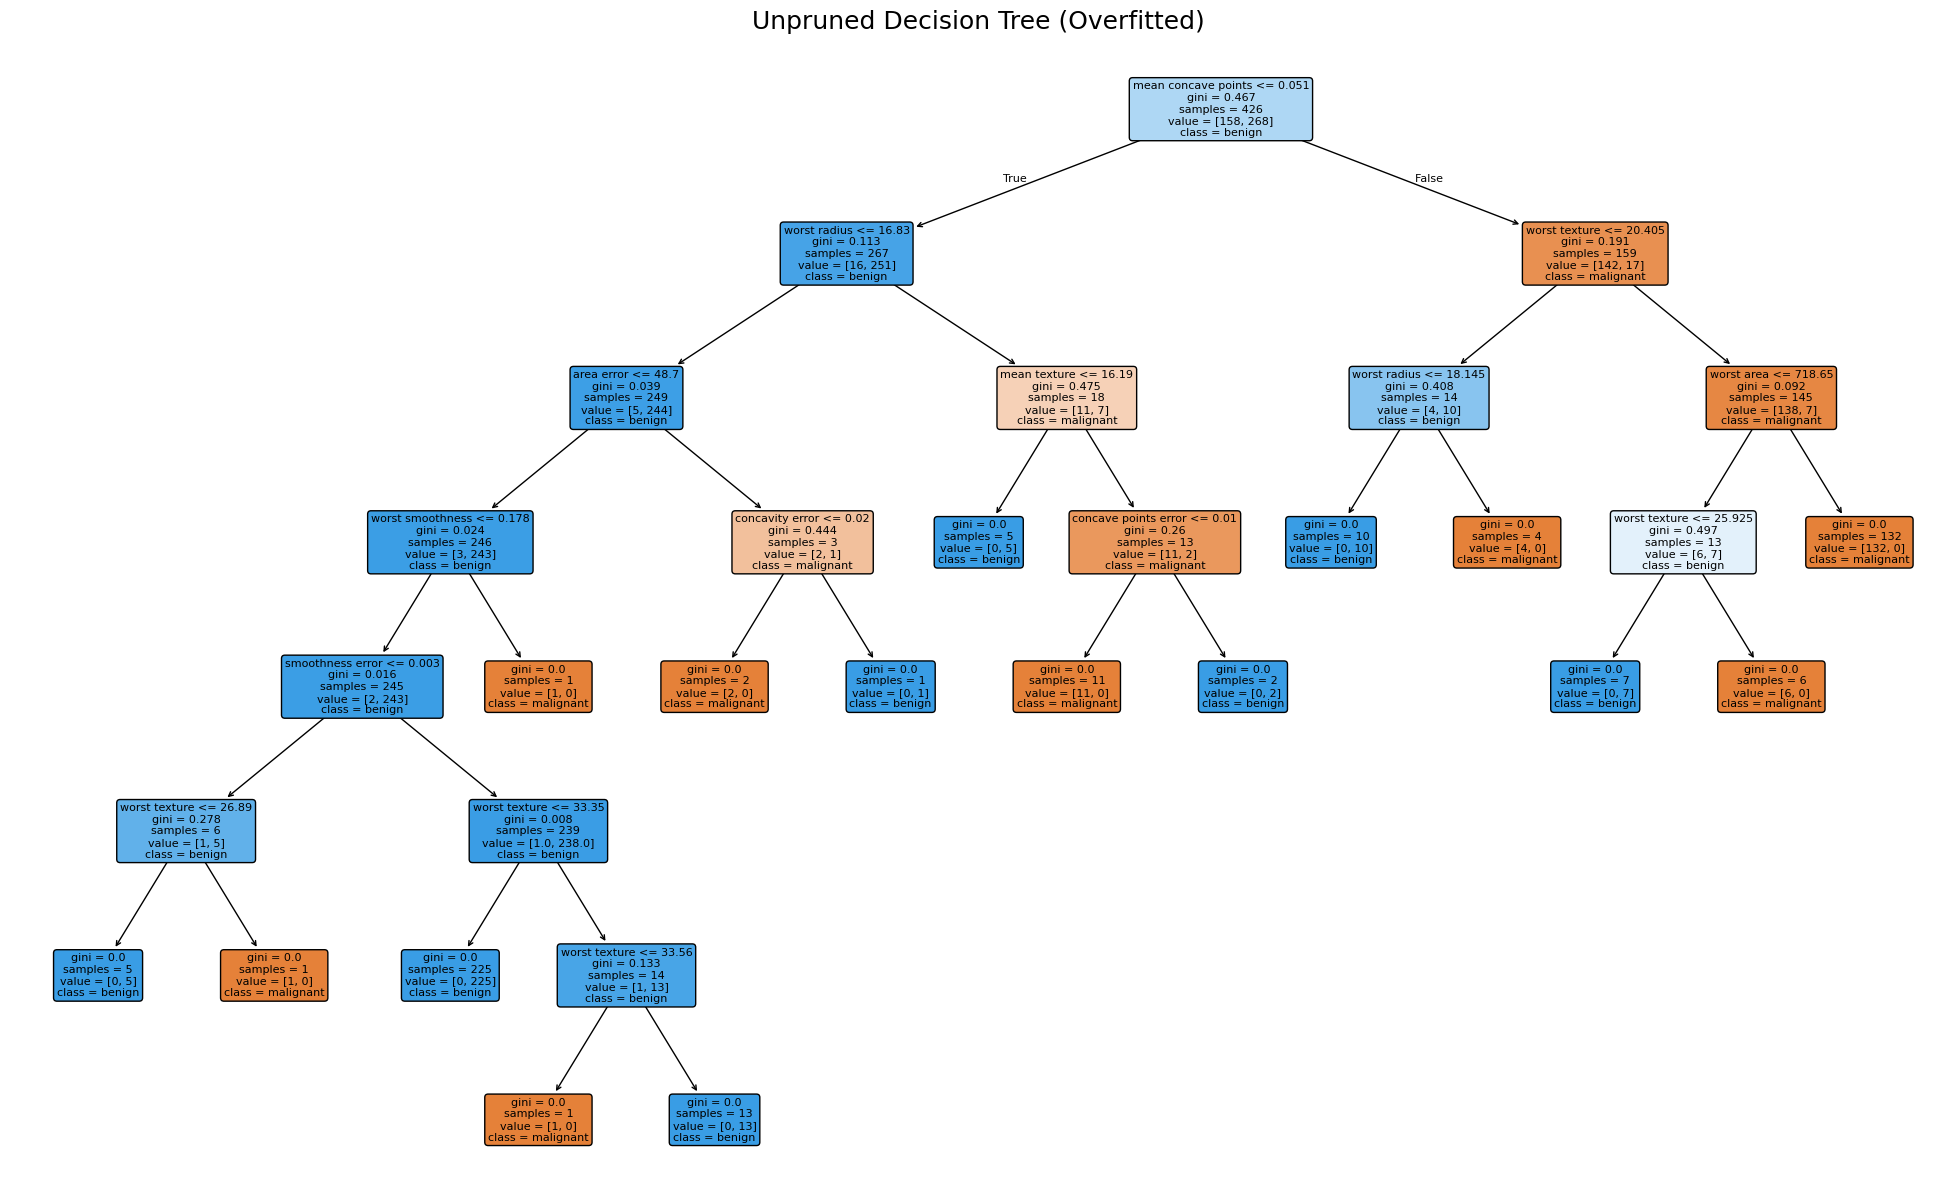

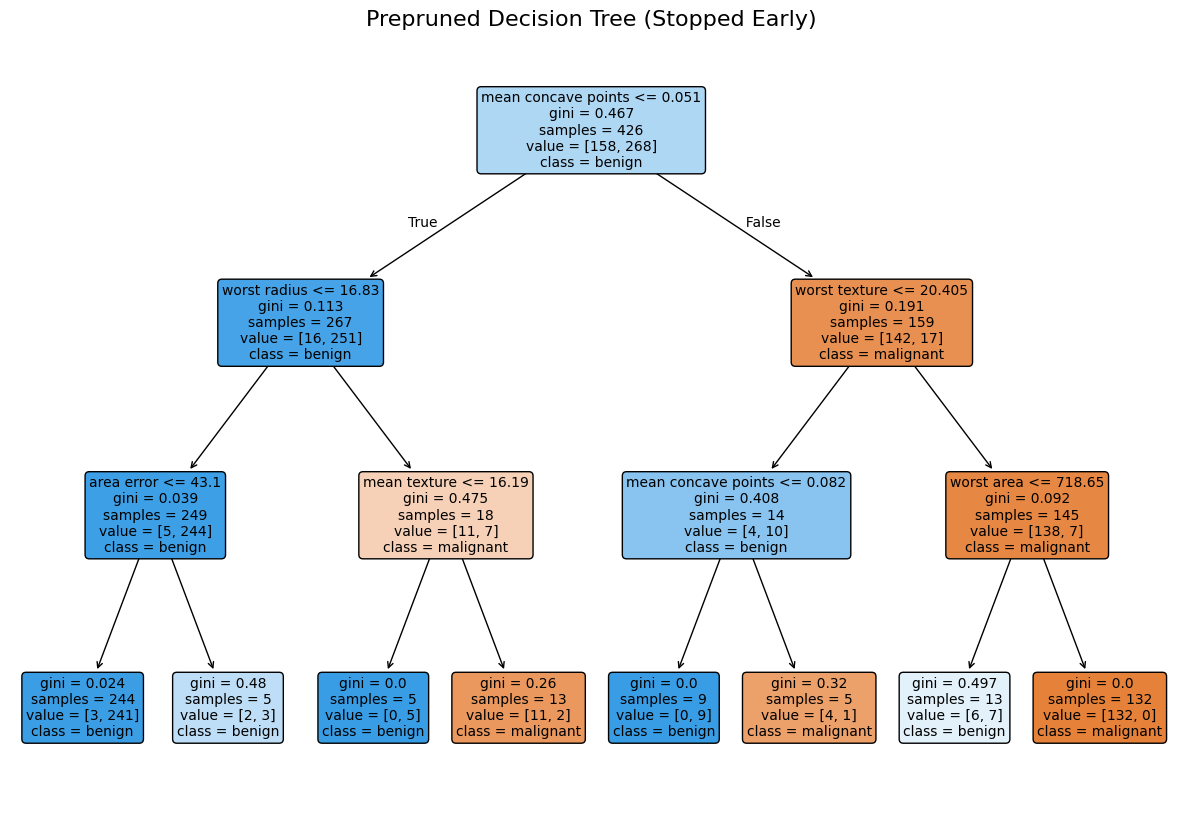

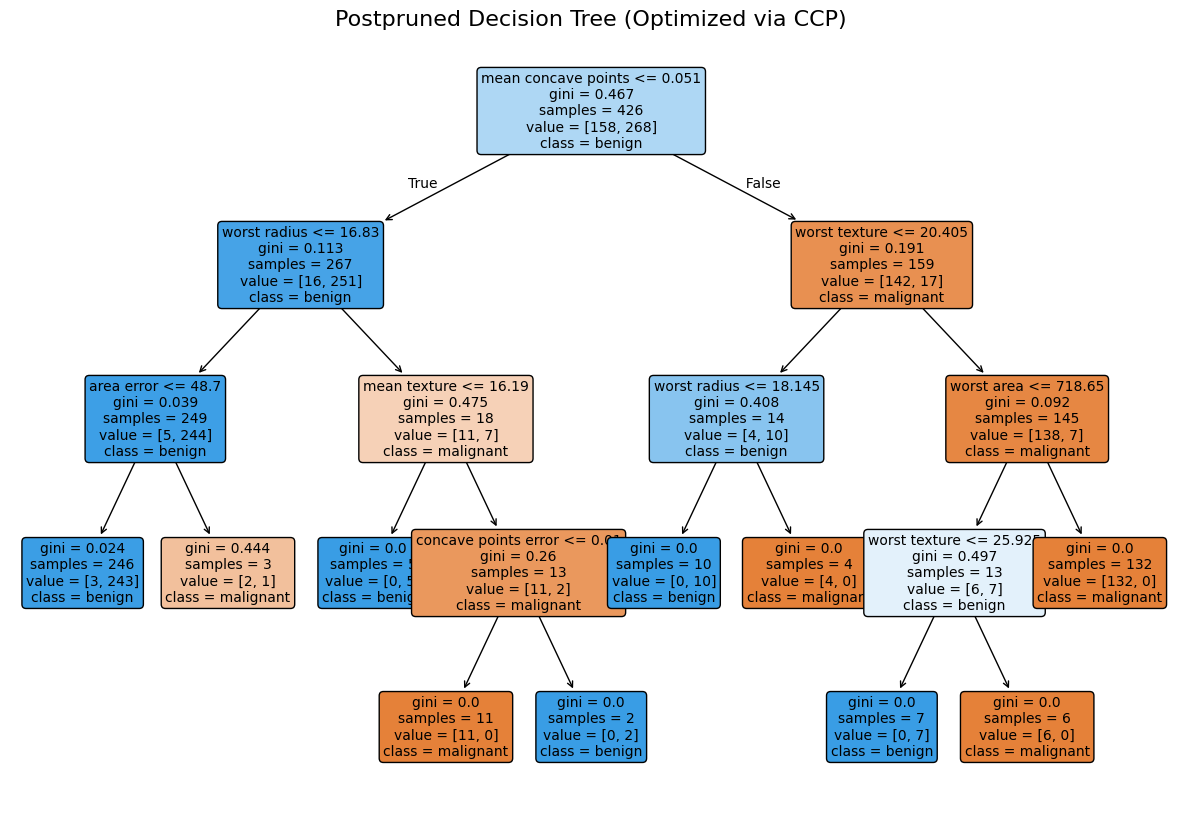

In [18]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.datasets import load_breast_cancer

# Load the dataset again just to grab the text labels for our features and classes
cancer_data = load_breast_cancer()
feature_names = cancer_data.feature_names
class_names = cancer_data.target_names

# --- 1. Plotting the Unpruned Tree ---
# We use a very large figure size because this tree is huge
plt.figure(figsize=(25, 15)) 
plot_tree(
    clf_unpruned, 
    feature_names=feature_names, 
    class_names=class_names, 
    filled=True,     # Colors the boxes based on the majority class
    rounded=True,    # Rounds the corners of the boxes
    fontsize=8       # Make font small to fit everything
)
plt.title("Unpruned Decision Tree (Overfitted)", fontsize=18)
plt.show()

# --- 2. Plotting the Prepruned Tree ---
# We can use a smaller figure size because depth is limited to 3
plt.figure(figsize=(15, 10))
plot_tree(
    clf_prepruned, 
    feature_names=feature_names, 
    class_names=class_names, 
    filled=True, 
    rounded=True,
    fontsize=10
)
plt.title("Prepruned Decision Tree (Stopped Early)", fontsize=16)
plt.show()

# --- 3. Plotting the Postpruned Tree ---
plt.figure(figsize=(15, 10))
plot_tree(
    best_clf_postpruned, 
    feature_names=feature_names, 
    class_names=class_names, 
    filled=True, 
    rounded=True,
    fontsize=10
)
plt.title("Postpruned Decision Tree (Optimized via CCP)", fontsize=16)
plt.show()